# Image Segmentation in CPU and GPU using PyTorch
## **A Tutorial on Classical and Differentiable Machine Learning Pipelines**

## **Introduction to Image Segmentation**
Image segmentation is the process of partitioning a digital image into multiple segments (sets of pixels) to simplify or change the representation of an image into something that is more meaningful and easier to analyze. 

For a given 2D image or 3D volume, our goal is to assign a discrete class label to every individual pixel based on its local structural, chemical, or morphological properties.

### **The Mathematics of Pixel-Wise Classification**
Let an input image be represented as a multi-dimensional array $X$, where $X_{i,j}$ denotes the feature vector (e.g., intensity, multi-channel spectra, or spatial characteristics) at pixel coordinates $(i, j)$. 

The segmentation task aims to find a mapping function $f(X_{i,j})$ that predicts a class label $y_{i,j}$ from a predefined set of discrete phases $Y = \{1, 2, \dots, K\}$:

$$f(X_{i,j}) \to y_{i,j} \in Y$$

To learn this mapping function from sparse annotations (where only a subset of pixels are manually labeled), we optimize the parameters of our classifier by minimizing a loss function. For a neural network or probabilistic classifier, this is typically the Cross-Entropy Loss ($\mathcal{L}$):

$$\mathcal{L} = -\frac{1}{N} \sum_{n=1}^{N} \sum_{k=1}^{K} t_{n,k} \log(p_{n,k})$$

Where:
* $N$ is the total number of annotated training pixels.
* $K$ is the number of distinct chemical or structural phases.
* $t_{n,k}$ is a binary indicator ($0$ or $1$) showing if class $k$ is the correct ground-truth label for pixel $n$.
* $p_{n,k}$ is the predicted probability assigned by the model that pixel $n$ belongs to class $k$.

---

## **Overview of the nDTomo Architecture**
This tutorial demonstrates the capabilities of the **`nDTomo.methods.segmentation`** and **`nDTomo.pytorch.segmentation_torch`** modules. Together, they form a unified framework inspired by trainable segmentation backends (such as Trainable Weka Segmentation and scikit-image) to perform multi-scale featurization and pixel classification. 

The framework decouples feature extraction from the classification engine, enabling three distinct workflows:

1. **The Classical CPU Pipeline (`methods.segmentation`):** Extracts high-dimensional spatial filter stacks (Gaussian blurs, Sobel edges, Hessians, and texture ranks) using multi-threaded CPU routines. These features are paired with sparse manual labels to train standard non-linear tree classifiers (like Random Forest or XGBoost) on host memory.
   
2. **The Accelerated Tensor Pipeline (`pytorch.segmentation_torch`):** Replicates the exact same mathematical filter operations entirely within PyTorch. By mapping the blurs and gradients to optimized 2D convolutions (`conv2d`, `max_pool2d`), the entire feature stack is generated on the GPU. This stack directly feeds a GPU-accelerated XGBoost engine, eliminating host-to-device memory transfer bottlenecks and providing massive performance speedups on massive tomographic slices.
   
3. **The Multi-Channel / Multi-Modal Pipeline:** Extends pixel-wise classification beyond simple grayscale intensities. By appending extra structural, chemical, or spectral channels directly to the spatial feature maps, the classifier is trained to segment complex materials where boundaries cannot be resolved by grayscale profiles alone.

---

## **Objectives**
In this notebook, we will step-by-step:
1. **Extract Morphological Features on CPU:** Generate multi-scale feature arrays using traditional computer vision filters to capture local neighborhood structures.
2. **Train and Compare CPU Classifiers:** Use sparse manual annotations to train Random Forest and XGBoost architectures via standard scikit-style workflows.
3. **Deploy GPU-Accelerated Pipelines:** Transition the featurization and classification tasks to PyTorch and CUDA tensors to demonstrate real-time execution profiles.
4. **Segment Complex Multi-Channel Data:** Incorporate auxiliary channel dimensions to isolate overlapping phases and export high-contrast structural segmentations.

In [1]:
import os
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
from h5py import File as h5file
from tifffile import imread
import time

# nDTomo Classical CPU Segmentation Engine
from nDTomo.methods.segmentation import (
    get_model as get_cpu_model,
    FeatureConfig,
    get_features as get_cpu_features,
    load_labels,
    get_training_data as get_cpu_training_data,
    fit_model as fit_cpu_model,
    apply as apply_cpu
)

# nDTomo PyTorch CPU/GPU Accelerated Segmentation Engine
from nDTomo.pytorch.segmentation_torch import (
    get_model as get_gpu_model,
    prepare_for_gpu,
    get_features as get_gpu_features,
    get_training_data as get_gpu_training_data,
    fit_model as fit_gpu_model,
    apply as apply_gpu
)

## **1. Environment Setup & Experimental Data Ingestion**

Before constructing our feature stacks, we map out filepaths and ingest our target tomographic data. In this tutorial, we work with real synchrotron data from a lithium-ion battery electrode. 

We load both a reference intensity image (or a sum-slice derived from a multi-channel reconstruction) along with a set of sparse, hand-drawn annotations (`labels`). These annotations provide the necessary coordinate indices used to guide our classifiers.

In [2]:
# Configure paths relative to the nDTomo repository structure
seg_dir_path = '../../../nDTomo/examples/segmentation/'

# Ingest the baseline single-channel grayscale structure
img_path = join(seg_dir_path, 'Battery_21700.tif')
mean_img = imread(img_path)

# Ingest sparse manual annotations (0 = Unlabelled, 1 = Phase A, 2 = Phase B, etc.)
labels_path = join(seg_dir_path, 'Battery_21700_labels.tif')
labels = load_labels(labels_path)

# Verify image space shapes
print(f"Grayscale target image dimension: {mean_img.shape}")
print(f"Sparse label array dimension:     {labels.shape}")
print(f"Unique class indices detected:    {np.unique(labels)}")


Grayscale target image dimension: (1568, 1568)
Sparse label array dimension:     (1568, 1568)
Unique class indices detected:    [0 1 2 3 4 5 6]


## **2. Workflow I: Classical Multi-Scale Featurization & Tabular CPU Classification**

The classical pipeline operates by converting our $H \times W$ grayscale intensity image into an $H \times W \times N_{\text{features}}$ multi-dimensional array. This process allows the model to analyze a pixel's local environment rather than just its single grayscale value.

### **Pipeline Components**
* **`FeatureConfig`:** Sets the kernel scales ($\sigma$) and activates specific filter banks (e.g., Gaussian blurs, Sobel edge profiles, Hessian eigenvalues, and local statistical ranks).
* **Multi-Threaded Extraction (`get_cpu_features`):** Computes individual filter arrays across multiple CPU threads, evaluating spatial structures for every individual pixel.
* **Sparse Label Extraction (`get_cpu_training_data`):** Drops all unlabelled pixels, pairing only the user-annotated coordinate positions with their corresponding high-dimensional feature vectors to create a balanced tabular training dataset.

In [3]:
# Initialize default multi-scale computer vision filter settings
cfg = FeatureConfig()

# Generate the high-dimensional feature stack on the CPU
start_time = time.time()
print("Computing multi-scale spatial filters on CPU...")
classical_features = get_cpu_features(mean_img, cfg)
cpu_feat_time = time.time() - start_time
print(f"Generated feature stack shape: {classical_features.shape} ({classical_features.shape[-1]} filters per pixel)")

# Isolate tabular arrays corresponding strictly to annotated pixel coordinates
X_train_cpu, y_train_cpu = get_cpu_training_data(classical_features, labels)
print(f"Tabular training matrix shape:  {X_train_cpu.shape}")
print(f"Tabular training target shape:  {y_train_cpu.shape}")

Computing multi-scale spatial filters on CPU...
Generated feature stack shape: (1568, 1568, 58) (58 filters per pixel)
Tabular training matrix shape:  (974, 58)
Tabular training target shape:  (974,)


## **3. Classifier Instantiation, Sparse Training, & Full-Slice Inference on CPU**

With our tabular training data matrix extracted, we select and configure our classification models. We test both a traditional Random Forest and a Gradient Boosted Tree model (XGBoost) running entirely on host memory. 

Because manual annotations are sparse and often biased toward specific high-contrast phases, we explicitly utilize balanced class weightings to prevent the tree splits from over-fitting to the most frequently painted material domains.

### **Pipeline Components**
* **`get_cpu_model`:** Instantiates an `XGBClassifier` optimized with custom hyperparameters (`max_depth`, `eta`, `gamma`) to balance learning speed and model generalization.
* **`fit_cpu_model`:** Trains the decision tree ensemble on the isolated training matrix, mapping the continuous scale feature values to zero-indexed integer targets ($Y - 1$).
* **`apply_cpu`:** Reshapes the final $H \times W \times N_{\text{features}}$ feature array into a flat tabular matrix, passes it through the trained classifier, and maps the predictions back into a discrete $H \times W$ segmentation mask.

In [4]:
from sklearn.ensemble import RandomForestClassifier
import time

# --- 1. Classical Random Forest Workflow ---
print("Initializing Random Forest Classifier on CPU...")
rf_model = RandomForestClassifier(max_depth=8, class_weight="balanced", random_state=42)

start_time = time.time()
rf_model.fit(X_train_cpu, y_train_cpu - 1)
cpu_rf_fit_time = time.time() - start_time

start_time = time.time()
# Flatten and predict pixel-wise across the full spatial resolution
h, w, n_feats = classical_features.shape
flat_feats = classical_features.reshape(-1, n_feats)
rf_segmentation = rf_model.predict(flat_feats).reshape(h, w)
cpu_rf_apply_time = time.time() - start_time

print(f"\nRandom Forest CPU - Features: {cpu_feat_time:.3f}s, Fit: {cpu_rf_fit_time:.3f}s, Apply: {cpu_rf_apply_time:.3f}s")
print(f"\nRandom Forest CPU Segmentation\nTotal Compute Time: {cpu_feat_time + cpu_rf_fit_time + cpu_rf_apply_time:.3f}s")

# --- 2. Advanced XGBoost CPU Workflow ---
print("\nInitializing XGBoost Classifier on CPU...")
xgb_cpu_model = get_cpu_model(max_depth=8, class_weight="balanced")

start_time = time.time()
xgb_cpu_model = fit_cpu_model(xgb_cpu_model, X_train_cpu, y_train_cpu)
cpu_xgb_fit_time = time.time() - start_time

start_time = time.time()
xgb_cpu_segmentation = apply_cpu(xgb_cpu_model, classical_features)
cpu_xgb_apply_time = time.time() - start_time

print(f"XGBoost CPU - Fit: {cpu_xgb_fit_time:.3f}s, Apply: {cpu_xgb_apply_time:.3f}s")

print(f"\nXGBoost CPU - Features: {cpu_feat_time:.3f}s, Fit: {cpu_xgb_fit_time:.3f}s, Apply: {cpu_xgb_apply_time:.3f}s")
print(f"\nXGBoost CPU Segmentation\nTotal Compute Time: {cpu_feat_time + cpu_xgb_fit_time + cpu_xgb_apply_time:.3f}s")


Initializing Random Forest Classifier on CPU...

Random Forest CPU - Features: 3.646s, Fit: 0.370s, Apply: 12.126s

Random Forest CPU Segmentation
Total Compute Time: 16.142s

Initializing XGBoost Classifier on CPU...


c:\Users\Antony\.conda\envs\ndtomo\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:09:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost CPU - Fit: 0.495s, Apply: 1.113s

XGBoost CPU - Features: 3.646s, Fit: 0.495s, Apply: 1.113s

XGBoost CPU Segmentation
Total Compute Time: 5.254s


### **3.1 Visual Evaluation of Classical CPU Segments**

We apply an explicit spatial overlay to contrast our predicted segmentations against the raw structural intensities. This step allows us to visually audit boundary correctness and check for typical pixel-wise speckle artifacts before testing hardware acceleration.

### **Visualization Layers**
* **`label2rgb` Overlay:** Blends discrete class matrices with grayscale structural profiles using high-contrast color bands.
* **Structural Subplots:** Side-by-side array mapping to inspect how effectively Random Forest and XGBoost isolated microstructural features on host memory.

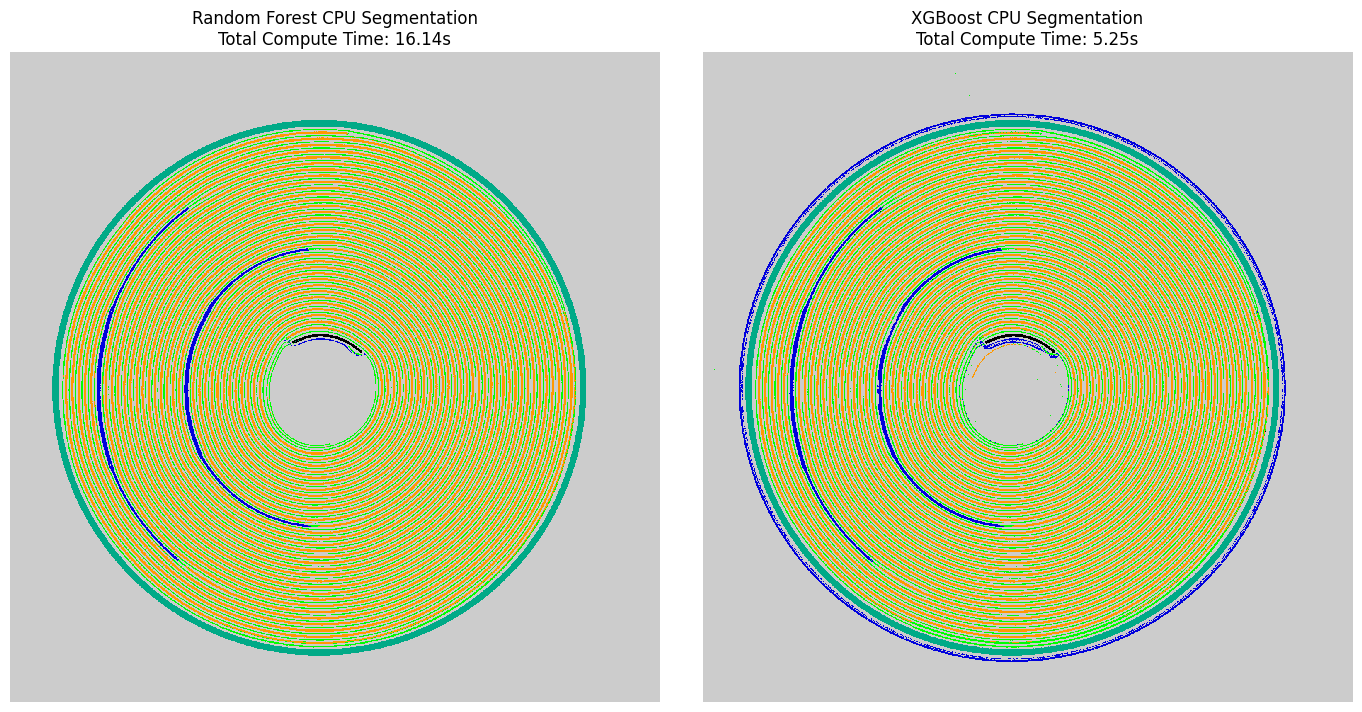

In [5]:
from skimage.color import label2rgb

# Cast uint8 predictions to signed int32 to safely allow negative bg_label checks inside skimage
rf_seg_signed = rf_segmentation.astype(np.int32)
xgb_seg_signed = xgb_cpu_segmentation.astype(np.int32)

# Construct side-by-side verification subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

axs[0].imshow(rf_seg_signed, cmap = 'nipy_spectral', interpolation = 'none')
axs[0].set_title(f"Random Forest CPU Segmentation\nTotal Compute Time: {cpu_feat_time + cpu_rf_fit_time + cpu_rf_apply_time:.2f}s", fontsize=12)
axs[0].axis("off")

axs[1].imshow(xgb_seg_signed, cmap = 'nipy_spectral', interpolation = 'none')
axs[1].set_title(f"XGBoost CPU Segmentation\nTotal Compute Time: {cpu_feat_time + cpu_xgb_fit_time + cpu_xgb_apply_time:.2f}s", fontsize=12)
axs[1].axis("off")

plt.tight_layout()
plt.show()

## **4. Workflow II: Differentiable-Ready GPU Tensor Acceleration via PyTorch**

When scaling up to large images or executing real-time interactive user adjustments, running spatial feature extractions and multi-tree loops on a host CPU creates a significant computational bottleneck. 

To bypass this limitation, we shift our entire matrix configuration over to PyTorch tensors. This allows the backend to perform multi-scale blurs, gradients, and neighborhood operations using highly optimized GPU 2D convolutional operators (`conv2d`) and parallelized max-pooling routines.

### **Tensor Optimization Arrays**
* **`prepare_for_gpu`:** Ingests raw NumPy slices, automatically expanding dimensions to meet PyTorch tensor expectations ($(H, W) \to (1, 1, H, W)$), and registers the array block directly into active CUDA memory.
* **`get_gpu_features`:** Replicates the exact multi-scale computer vision filter combinations entirely inside the GPU, outputting an accelerated tensor feature array.
* **`get_gpu_model`:** Instantiates an XGBoost engine explicitly configured for graphics hardware devices (`device="cuda"`, `tree_method="hist"`), eliminating host-to-device memory transfer latency during training steps.

In [ ]:
import time
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Move our baseline single-channel matrix and sparse labels onto the GPU
print("Transferring single-channel data arrays to GPU device...")
image_tensor = prepare_for_gpu(mean_img, device=device)
labels_tensor = prepare_for_gpu(labels, device=device)

# Generate the high-dimensional spatial feature stack natively in CUDA memory
start_time = time.time()
gpu_features = get_gpu_features(image_tensor, cfg)
gpu_feat_time = time.time() - start_time
print(f"GPU feature tensor configuration: {gpu_features.shape}")

# Extract and isolate tabular training subsets entirely within GPU memory spaces
X_train_gpu, y_train_gpu = get_gpu_training_data(gpu_features, labels_tensor)
print(X_train_gpu.device, y_train_gpu.device)

# Instantiate the hardware-accelerated classifier execution layer
xgb_gpu_model = get_gpu_model(max_depth=8, class_weight="balanced")

# Fit the model and execute pixel-wise inference directly on the GPU features
start_time = time.time()
xgb_gpu_model = fit_gpu_model(xgb_gpu_model, X_train_gpu, y_train_gpu)
gpu_fit_time = time.time() - start_time

start_time = time.time()
xgb_gpu_segmentation = apply_gpu(xgb_gpu_model, gpu_features)
gpu_apply_time = time.time() - start_time

print(f"\nXGBoost GPU - Features: {gpu_feat_time:.3f}s, Fit: {gpu_fit_time:.3f}s, Apply: {gpu_apply_time:.3f}s")
print(f"\nXGBoost GPU Segmentation\nTotal Compute Time: {gpu_feat_time + gpu_fit_time + gpu_apply_time:.3f}s")


Transferring single-channel data arrays to GPU device...
GPU feature tensor configuration: torch.Size([1568, 1568, 58])
cuda:0 cuda:0


c:\Users\Antony\.conda\envs\ndtomo\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:09:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Antony\.conda\envs\ndtomo\Lib\site-packages\xgboost\core.py:751: UserWarning: [14:09:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



XGBoost GPU - Features: 0.465s, Fit: 0.806s, Apply: 2.325s

XGBoost GPU Segmentation
Total Compute Time: 3.595s


### **4.1 Visual Evaluation of GPU Accelerated Predictions**

We map our GPU-derived segmentation masks back into standard display spaces. This validates that porting our multi-scale mathematical filters into PyTorch convolutions yields identical phase distributions while executing at a fraction of the computation time.

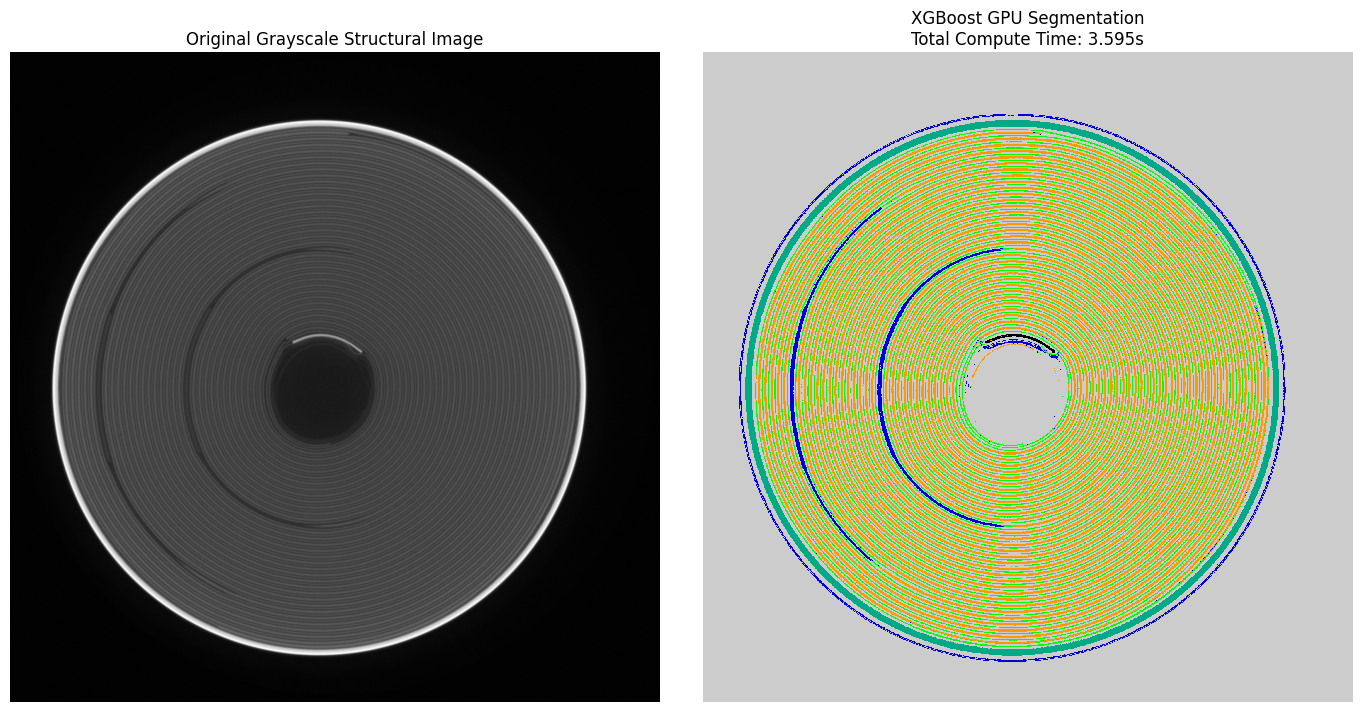

In [7]:
# Cast the GPU output array to int32 to safely support the visualization utility functions
gpu_seg_signed = xgb_gpu_segmentation.astype(np.int32)

# Construct side-by-side verification subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

axs[0].imshow(mean_img, cmap="gray")
axs[0].set_title("Original Grayscale Structural Image", fontsize=12)
axs[0].axis("off")

axs[1].imshow(gpu_seg_signed, cmap = 'nipy_spectral', interpolation = 'none')
axs[1].set_title(f"XGBoost GPU Segmentation\nTotal Compute Time: {gpu_feat_time + gpu_fit_time + gpu_apply_time:.3f}s", fontsize=12)
axs[1].axis("off")

plt.tight_layout()

## **5. Workflow III: Advanced Multi-Channel / Multi-Modal Segmentation Arrays**

In chemical imaging or tomography (such as XRD-CT), isolating target phases from a single grayscale channel can fail if distinct compounds share identical structural densities. 

To overcome this, we transition to a multi-channel pipeline. We use our primary single-channel array alongside auxiliary channels (e.g., specific chemical maps, component loadings, or elemental slices). We append these multi-dimensional channels directly to our spatial feature stack, forcing our tree splits to evaluate both morphological context and underlying multi-modal profiles simultaneously.

### **Pipeline Components**
* **Auxiliary Channel Appending (`get_cpu_features`):** Integrates additional 2D data arrays directly into the final dimensions of the feature tensor.
* **Multi-Modal Pixel Tabulation:** Maps both the calculated local neighborhood filters and the explicit raw channel values into a unified tabular matrix for every pixel.

In [8]:
import h5py

fn = r"C:\Users\Antony\Documents\GitHub\nDTomo\nDTomo\examples\segmentation\Battery_21700_extra.h5"
with h5py.File(fn, 'r') as f:
    extra_channels = f['data'][:]

print(f"Extra channels shape: {extra_channels.shape}")

Extra channels shape: (1568, 1568, 6)


In [9]:

print(f"Shape of auxiliary multi-modal channels: {extra_channels.shape}")

# Generate features on CPU, appending the extra spatial arrays directly to the filter stack
print("Extracting multi-scale filters with auxiliary multi-channel profiles...")
multichannel_features = get_cpu_features(mean_img, cfg, extra_channels)
print(f"Multi-channel feature stack shape: {multichannel_features.shape}")

# Re-extract sparse training records using our multi-channel matrix
X_train_multi, y_train_multi = get_cpu_training_data(multichannel_features, labels)

# Re-instantiate and fit our classifier using the enhanced multi-modal data matrix
multichannel_model = get_cpu_model(max_depth=8, class_weight="balanced")
multichannel_model = fit_cpu_model(multichannel_model, X_train_multi, y_train_multi)

# Predict across the full multi-channel spatial frame
multichannel_segmentation = apply_cpu(multichannel_model, multichannel_features)
print("Multi-channel segmentation execution complete.")

Shape of auxiliary multi-modal channels: (1568, 1568, 6)
Extracting multi-scale filters with auxiliary multi-channel profiles...
Multi-channel feature stack shape: (1568, 1568, 64)


c:\Users\Antony\.conda\envs\ndtomo\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:09:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Multi-channel segmentation execution complete.


## **6. Full Comprehensive Structural Reporting**

We complete our tutorial by visualizing the final multi-channel classification against our baseline single-channel workflows. This highlights the value of appending extra chemical dimensions to resolve ambiguous phase boundaries.

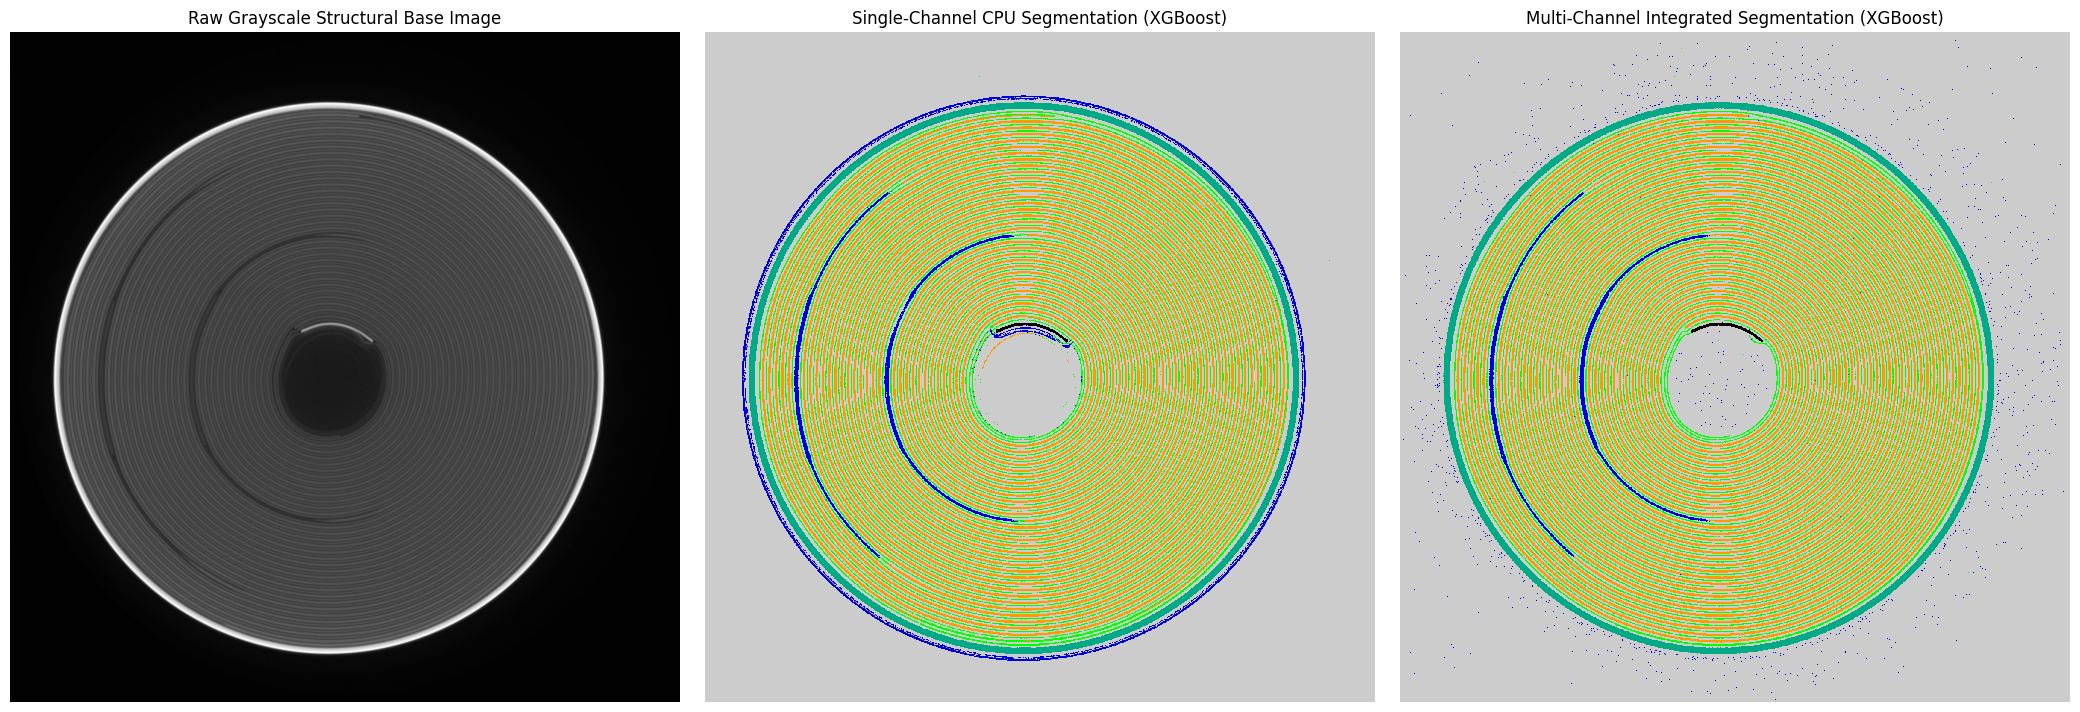

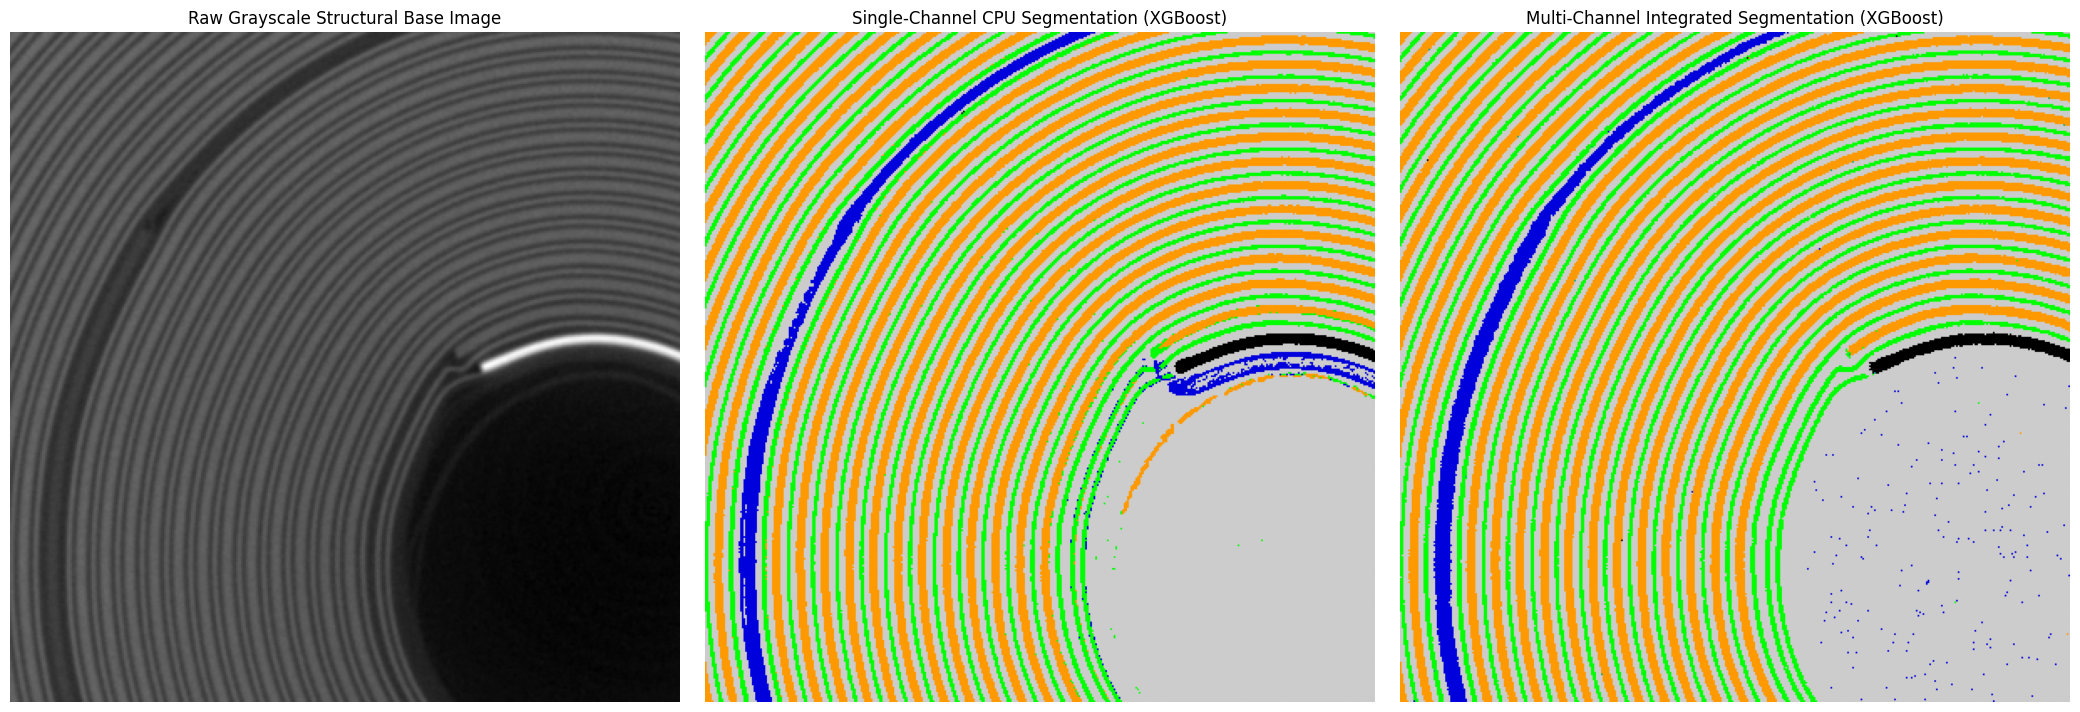

In [10]:
# Cast the final multi-channel prediction array to int32
multi_seg_signed = multichannel_segmentation.astype(np.int32)


# Plot a comprehensive final comparison layout
fig, axs = plt.subplots(1, 3, figsize=(21, 7))

axs[0].imshow(mean_img, cmap="gray")
axs[0].set_title("Raw Grayscale Structural Base Image", fontsize=12)
axs[0].axis("off")

axs[1].imshow(xgb_seg_signed, cmap = 'nipy_spectral', interpolation = 'none')
axs[1].set_title("Single-Channel CPU Segmentation (XGBoost)", fontsize=12)
axs[1].axis("off")

axs[2].imshow(multi_seg_signed, cmap = 'nipy_spectral', interpolation = 'none')
axs[2].set_title("Multi-Channel Integrated Segmentation (XGBoost)", fontsize=12)
axs[2].axis("off")

plt.tight_layout()
plt.show()


# Plot a comprehensive final comparison layout
fig, axs = plt.subplots(1, 3, figsize=(21, 7))

axs[0].imshow(mean_img[500:900, 400:800], cmap="gray")
axs[0].set_title("Raw Grayscale Structural Base Image", fontsize=12)
axs[0].axis("off")

axs[1].imshow(xgb_seg_signed[500:900, 400:800], cmap = 'nipy_spectral')
axs[1].set_title("Single-Channel CPU Segmentation (XGBoost)", fontsize=12)
axs[1].axis("off")

axs[2].imshow(multi_seg_signed[500:900, 400:800], cmap = 'nipy_spectral')
axs[2].set_title("Multi-Channel Integrated Segmentation (XGBoost)", fontsize=12)
axs[2].axis("off")

plt.tight_layout()
plt.show()

## **7. Summary & Structural Insights**

In this tutorial, we implemented a complete multi-scale feature-extraction and tabular pixel-classification pipeline using **`nDTomo`**. We transitioned the workflow from traditional CPU libraries to an accelerated PyTorch framework, and finally extended it to multi-channel imaging datasets.

### **Core Key Takeaways**
* **Feature-Based Mapping:** Casting image segmentation as a pixel-wise tabular machine learning problem allows us to build highly flexible, interactive workflows. We can train powerful decision tree models (Random Forest and XGBoost) using only a small set of sparse, hand-drawn annotations rather than thousands of fully labeled images.
* **PyTorch Acceleration Benefits:** Shifting the spatial filtering logic into a PyTorch execution layer allows us to use optimized 2D convolutions (`conv2d`) directly on the GPU. This eliminates the host-to-device memory transfer overheads caused by bouncing arrays back to CPU libraries, achieving massive hardware speedups that make interactive real-time tuning possible on large tomographic slices.
* **Multi-Modal Extension:** Single-channel grayscale intensity arrays often fail to separate phases that share identical structural densities. Appending extra data arrays (such as chemical maps or component loadings) directly into the feature stack allows the classifier to simultaneously analyze both morphological neighborhood structures and multi-modal chemical profiles.
